# Nacitanie dat

In [192]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import matplotlib.ticker as ticker


In [193]:
donations = pd.read_csv("data_sources/donations.csv")
print(f"sucet prispevkov: {sum(donations['amount'])} €\n")
print(donations["amount"].describe())
donations["sex"] = donations["sex"].replace({None:"firma"})


sucet prispevkov: 73821898.78 €

count    2.219800e+04
mean     3.325610e+03
std      3.265485e+04
min      0.000000e+00
25%      2.000000e+01
50%      6.639000e+01
75%      6.000000e+02
max      2.000000e+06
Name: amount, dtype: float64


# Vizualizacie

## typ vs celkova suma

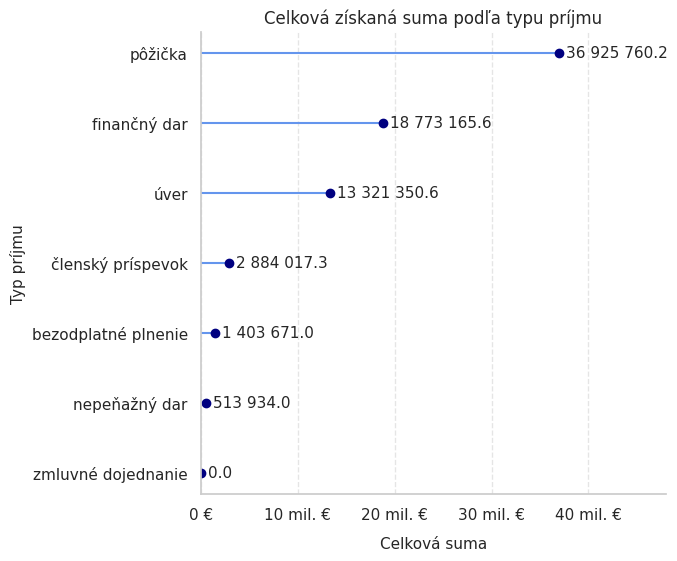

In [194]:
df = donations.groupby(["income_type"])["amount"].sum()
ordered_df = df.sort_values(ascending=True).reset_index()
fig, ax = plt.subplots(figsize=(6, 6))

my_range = range(1, len(ordered_df) + 1) 
plt.hlines(y=my_range, xmin=0, xmax=ordered_df['amount'], color='cornflowerblue')
plt.plot(ordered_df['amount'], my_range, "o",color="navy")
plt.yticks(my_range, ordered_df["income_type"])

x_offset =ordered_df["amount"].max() * 0.02
for i in range(len(my_range)):
    offseted = ordered_df["amount"][i] + x_offset
    plt.text(
        x=offseted, 
        y=my_range[i],
        s=f"{round(ordered_df['amount'][i],1):,}".replace(",", " "),
        va="center", 
        size=11
    )

plt.xlim(0, ordered_df["amount"].max() * 1.3)


# # Remove the unnecessary box borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.grid(axis="y", visible=False)
plt.gca().set_axisbelow(True)  # Keeps grid lines behind your bars/dots

def million_formatter(x, pos):
    return f"{x*1e-6:.0f} mil. €" if x != 0 else "0 €"
def million_formatter2(x, pos):
    return f"{x*1e-6:.1f} mil. €" if x != 0 else "0 €"
# def hundred_thousands_formatter(x,pos):
#     return f"{x*1e-4:.0f} tis. €" if x!=0 else "0"

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))
plt.xlabel("Celková suma", fontsize=11, labelpad=10)
plt.ylabel("Typ príjmu",fontsize=11)
plt.title("Celková získaná suma podľa typu príjmu")
plt.show()

## boxplot podla typu 

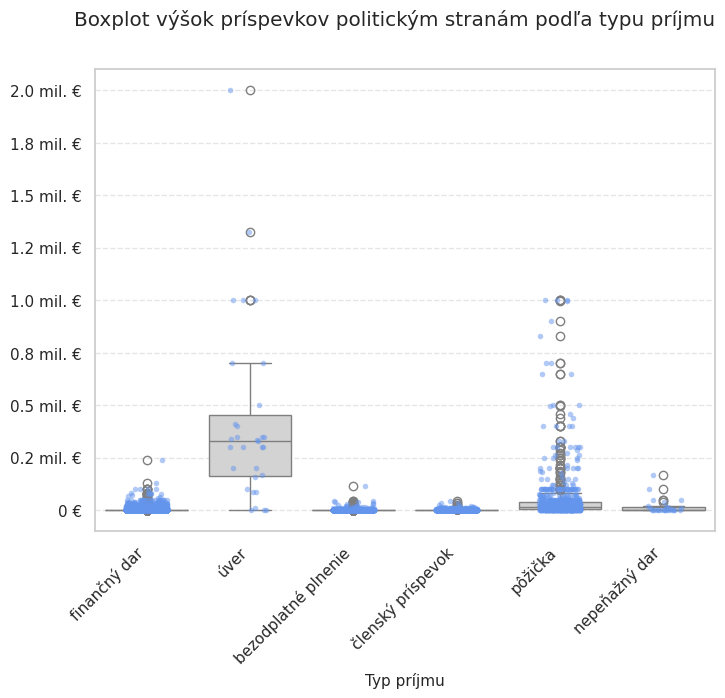

In [195]:
sns.set_theme(style="whitegrid")
df = donations.loc[donations["income_type"]!="zmluvné dojednanie"].copy()
#remove zmluvne doj kedze su iba 2 zmluvy
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df,x="income_type",y="amount",width=.8,color="lightgray")
sns.stripplot(data=df,x="income_type",y="amount",size=4,jitter=0.2,alpha=0.5,color="cornflowerblue")
# plt.xlabel("Celková suma", fontsize=11, labelpad=10)
plt.xticks(rotation=45,ha='right')
plt.ylabel("", fontsize=11)
plt.suptitle("Boxplot výšok príspevkov politickým stranám podľa typu príjmu")


#shortened y axis
# plt.ylim(0,1e6)
# plt.title("Orezané na max. 1 milión",fontsize=10)


plt.xlabel("Typ príjmu",fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(million_formatter2))


## histogram

In [196]:
list_donations = ['finančný dar', 'nepeňažný dar', 'bezodplatné plnenie','členský príspevok']
list_credits = ['úver', 'pôžička']

donations_only = donations[donations["income_type"].isin(list_donations)]
credits = donations[donations["income_type"].isin(list_credits)]

df["category"] = ["donation" if x in list_donations else "credit" for x in df["income_type"]]


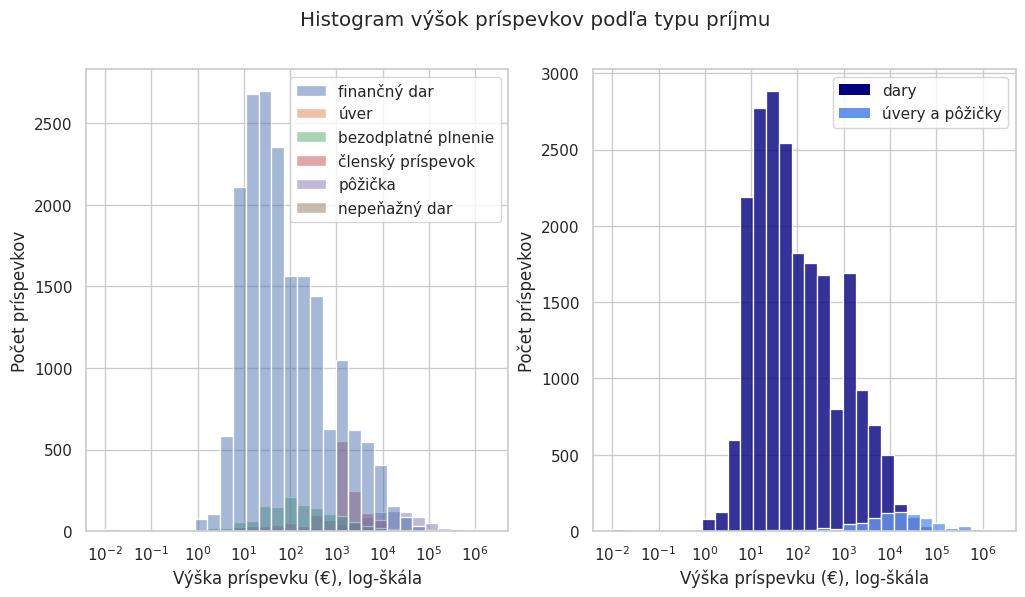

In [197]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
my_palette = ["cornflowerblue","navy"]

sns.histplot(data=df,x="amount",hue="income_type",log_scale=True,common_norm=False,ax=ax[0],bins=30,legend=True)
ax[0].legend_.set_title("")

sns.histplot(data=df,x="amount",hue="category",hue_order=["credit","donation"],log_scale=True,common_norm=False,ax=ax[1],palette=my_palette,alpha=0.8,bins=30,legend=False)

def legend_twocolors(pos):
    topbar = plt.Rectangle((0,0),1,1,fc="navy", edgecolor = 'none')
    bottombar = plt.Rectangle((0,0),1,1,fc='cornflowerblue',  edgecolor = 'none')
    l = plt.legend([topbar,bottombar], ['dary','úvery a pôžičky'], loc=pos, ncol = 1, prop={'size':11})
    l.draw_frame(True) 
legend_twocolors(1)
plt.suptitle("Histogram výšok príspevkov podľa typu príjmu")
for i in range(2):
    ax[i].set_xlabel("Výška príspevku (€), log-škála")
    ax[i].set_ylabel("Počet príspevkov") 
# print(df.sort_values("amount",ascending=True).head())

## Rebricek

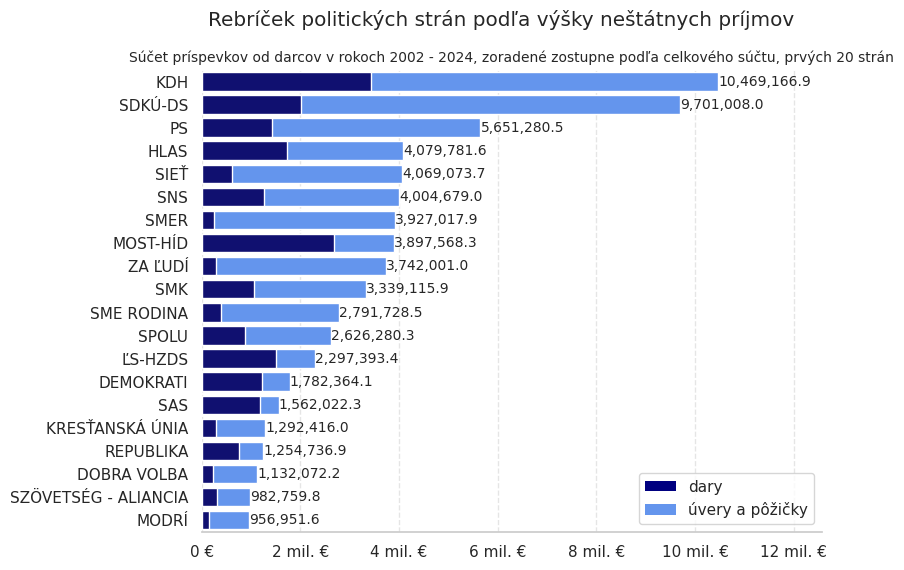

In [198]:
df1 = donations.groupby("party")["amount"].sum().reset_index().sort_values("amount",ascending=False).head(20)
# print(df1)
ordering =list(df1["party"])

df2 = donations_only.groupby("party")["amount"].sum().reset_index().sort_values("amount",ascending=False)

fig,ax = plt.subplots(figsize=(8,6))
bar1 = sns.barplot(data=df1,x="amount",y="party",color="cornflowerblue",saturation=1)
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.1f}")
#total suma ukazuje napravo..
bar2 = sns.barplot(data=df2,x="amount",y="party",order=ordering,color="navy")
# ax.bar_label(ax.containers[1],fontsize=10,label_type="center",color="white")


legend_twocolors(4)


sns.despine(left=True)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))

plt.xlim(0, df1["amount"].max() * 1.2)
plt.xlabel("")
plt.ylabel("",)
plt.suptitle("Rebríček politických strán podľa výšky neštátnych príjmov")
plt.title("Súčet príspevkov od darcov v rokoch 2002 - 2024, zoradené zostupne podľa celkového súčtu, prvých 20 strán",fontsize=10)
pass


## pocet unikatnych darcov

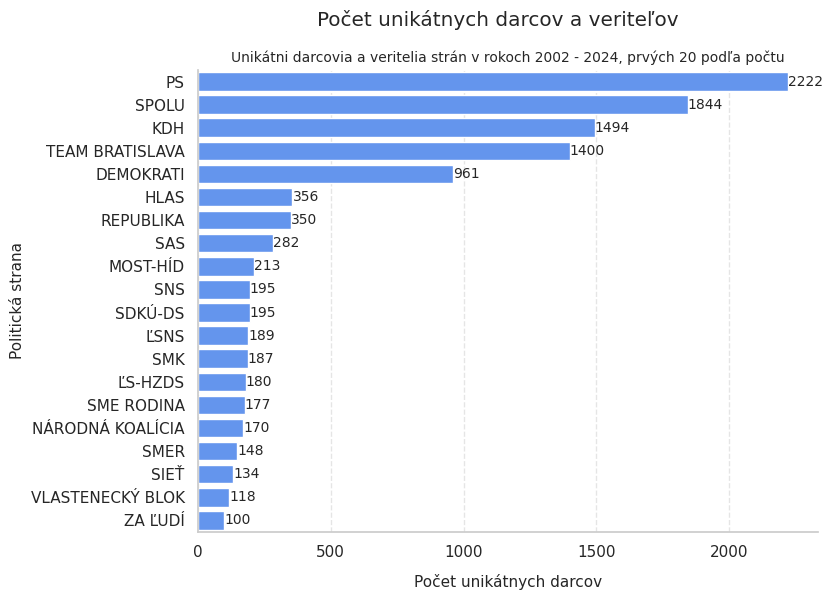

In [199]:
df_cleared = df.drop_duplicates(subset=["party_id", "user_id"], keep="first",inplace=False)
df1 = df_cleared.groupby("party")["user_id"].nunique().reset_index(name="unique").sort_values("unique",ascending=False).head(20)
ax = sns.barplot(data=df1,x="unique",y="party",color="cornflowerblue",saturation=1)
ax.bar_label(ax.containers[0],fontsize=10)
sns.set_context({"figure.figsize": (8, 6)})
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
sns.despine()
plt.suptitle("Počet unikátnych darcov a veriteľov")
plt.title("Unikátni darcovia a veritelia strán v rokoch 2002 - 2024, prvých 20 podľa počtu",fontsize=10)
plt.xlabel("Počet unikátnych darcov", fontsize=11, labelpad=10)
plt.ylabel("Politická strana", fontsize=11)
pass

## vysky darov podla krajov

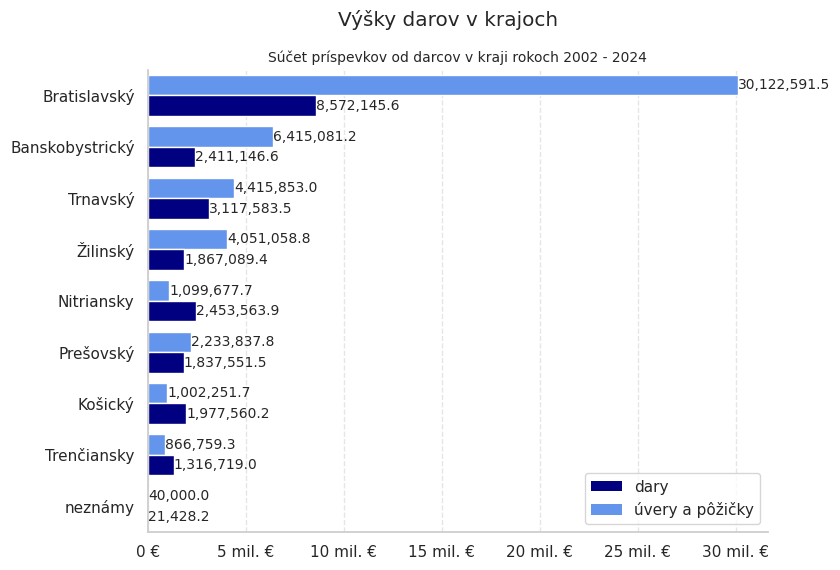

In [200]:
df1 = df.groupby(["region","category"])["amount"].sum().reset_index().sort_values("amount",ascending=False)
fig,ax = plt.subplots(figsize=(8,6))
sns.barplot(data=df1,x="amount",y="region",hue="category",palette = my_palette,saturation=1,legend=False)
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.1f}")
ax.bar_label(ax.containers[1],fontsize=10,fmt="{:,.1f}")
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))
plt.suptitle("Výšky darov v krajoch")
plt.title("Súčet príspevkov od darcov v kraji rokoch 2002 - 2024",fontsize=10)
plt.ylabel("")
plt.xlabel("")


legend_twocolors(4)

## unikatni darcovia v krajoch

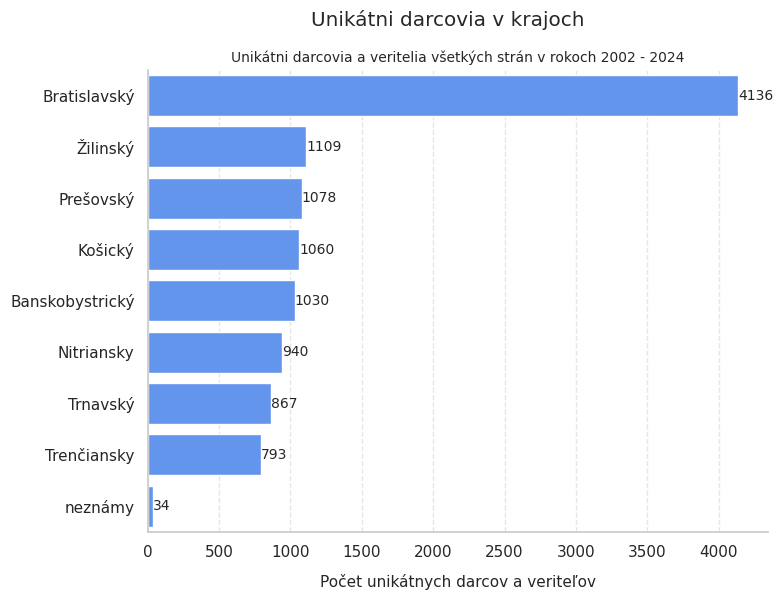

In [201]:
df_cleared = df.drop_duplicates(subset=["user_id"], keep="first",inplace=False)
df1 = df_cleared.groupby("region")["user_id"].size().reset_index(name="unique").sort_values("unique",ascending=False)

# print(sum(df1["unique"]))
fig,ax = plt.subplots(figsize=(8,6))
sns.barplot(data=df1,x="unique",y="region",color="cornflowerblue",saturation=1)
ax.bar_label(ax.containers[0],fontsize=10)
sns.despine()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Počet unikátnych darcov a veriteľov", fontsize=11, labelpad=10)
plt.suptitle("Unikátni darcovia v krajoch")
plt.title("Unikátni darcovia a veritelia všetkých strán v rokoch 2002 - 2024",fontsize=10)
plt.ylabel("")
pass


## vysky darov podla pohlavia

/tmp/ipykernel_89567/2263499448.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xticklabels=["firma", "muži", "ženy"])


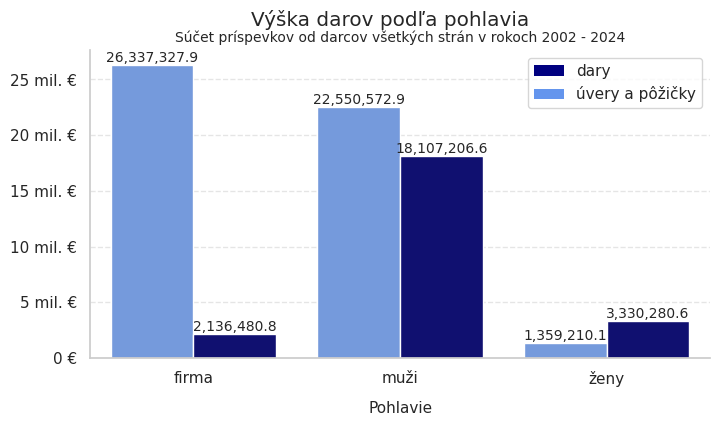

In [202]:
df1 = df.groupby(["sex","category"], dropna=False)["amount"].sum().reset_index().sort_values("amount",ascending=False)
# print(df1)
fig,ax = plt.subplots(figsize=(8,4))
sns.barplot(data=df1,x="sex",y="amount",hue="category",palette=my_palette,order=["firma","M","F"])
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(million_formatter))
ax.set(xticklabels=["firma", "muži", "ženy"])
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.1f}")
ax.bar_label(ax.containers[1],fontsize=10,fmt="{:,.1f}")
plt.suptitle("Výška darov podľa pohlavia")
plt.title("Súčet príspevkov od darcov všetkých strán v rokoch 2002 - 2024",fontsize=10)

legend_twocolors(1)


sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Pohlavie", fontsize=11, labelpad=10)
plt.ylabel("")
pass

## pocet darcov podla pohlavia

11047


/tmp/ipykernel_89567/3946447712.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(xticklabels=["muži", "ženy","firma"])


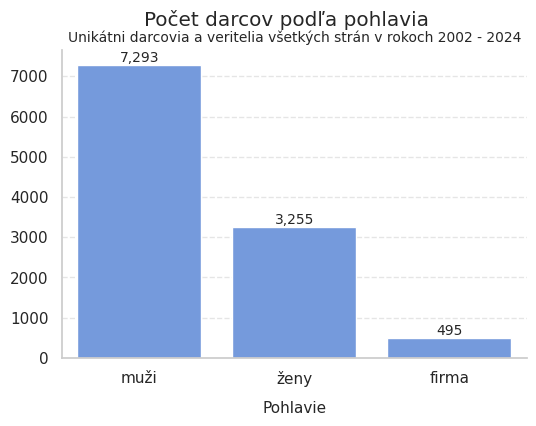

In [205]:
df_cleared = df.drop_duplicates(subset=["user_id"], keep="first",inplace=False)
df1 = df_cleared.groupby("sex")["user_id"].count().reset_index(name="count").sort_values("count",ascending=False)
print(sum(df1["count"]))
# mne vychadza 11047 ako aj by clovek cakal
# im vychadza 10660

# print(df1)
fig,ax = plt.subplots(figsize=(6,4))
sns.barplot(data=df1,x="sex",y="count",order=["M","F","firma"],color="cornflowerblue")
plt.suptitle("Počet darcov podľa pohlavia")
plt.title("Unikátni darcovia a veritelia všetkých strán v rokoch 2002 - 2024",fontsize=10)
ax.set(xticklabels=["muži", "ženy","firma"])
ax.bar_label(ax.containers[0],fontsize=10,fmt="{:,.0f}")
sns.despine()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.gca().set_axisbelow(True)
plt.xlabel("Pohlavie", fontsize=11, labelpad=10)
plt.ylabel("")
pass

## analyza datumov a maximalnej vysky

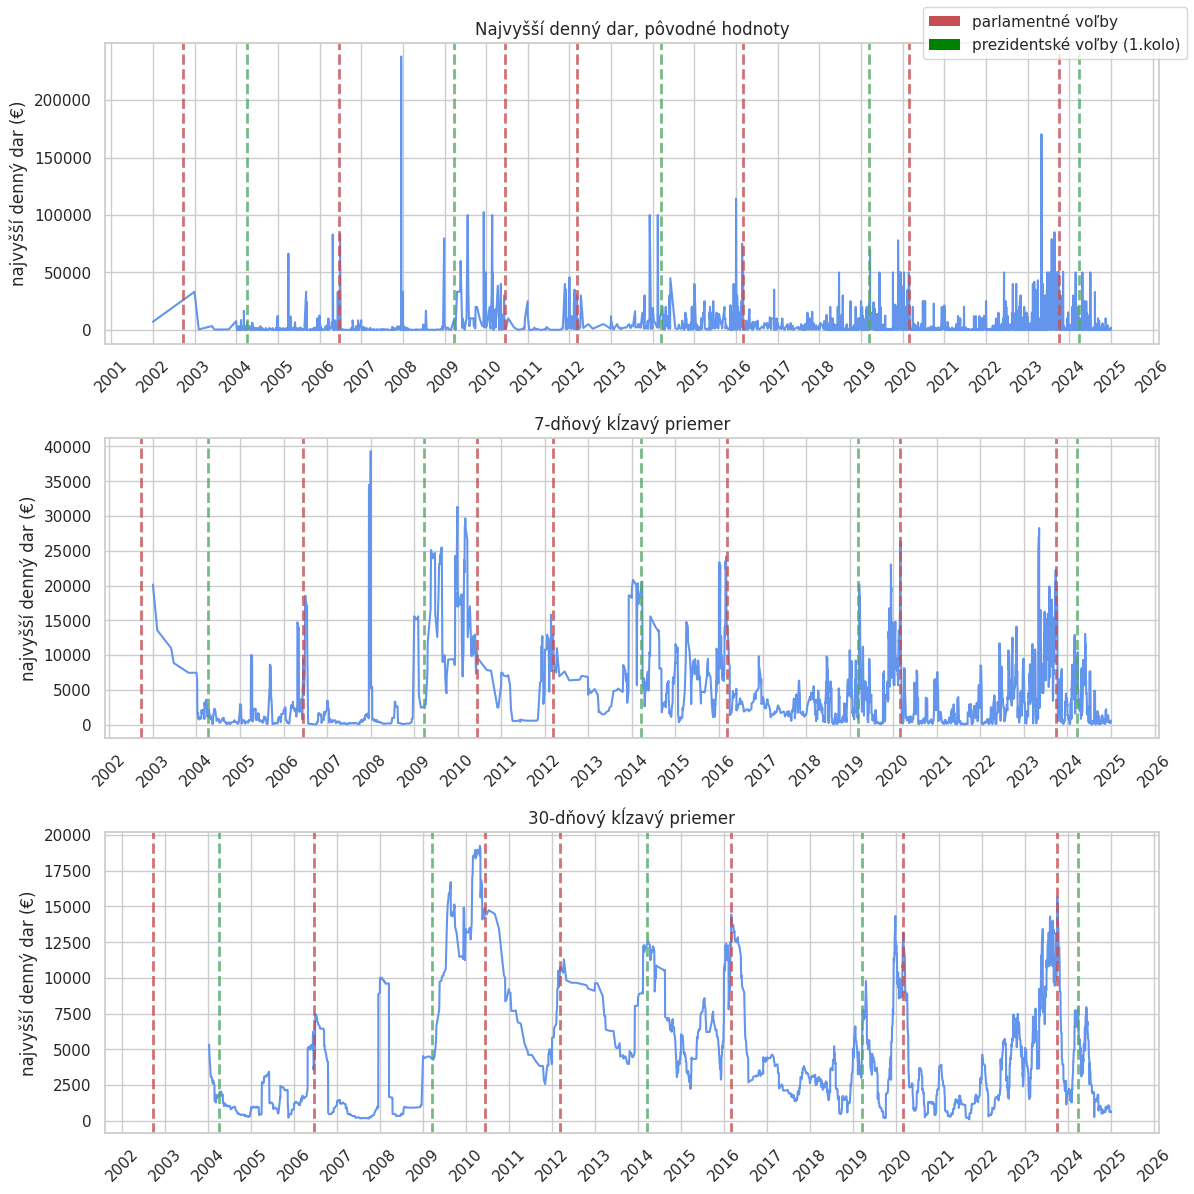

In [204]:
df1 = donations_only.copy()
# df1 = credits.copy()

df1['date'] = pd.to_datetime(df['date'],format='mixed')
df1.sort_values('date', inplace=True)

df2 = df1.groupby("date")["amount"].max()
rolling7 = df2.rolling(7,min_periods=2).mean()
rolling30 = df2.rolling(30,min_periods=10).mean()

fig,ax = plt.subplots(3,1,figsize=(12,12))
sns.lineplot(data=df2,ax=ax[0],color="cornflowerblue")
sns.lineplot(data=rolling7,ax=ax[1],color="cornflowerblue")
sns.lineplot(data=rolling30,ax=ax[2],color="cornflowerblue")

election_years = pd.read_csv("data_sources/election_dates.csv",sep=";")
election_years = election_years.apply(pd.to_datetime,format="%Y-%m-%d")
ax[0].set_title("Najvyšší denný dar, pôvodné hodnoty")
ax[1].set_title("7-dňový kĺzavý priemer")
ax[2].set_title("30-dňový kĺzavý priemer")

import matplotlib.dates as mdates

for i in range(3):
    ax[i].xaxis.set_major_locator(mdates.YearLocator(1)) # Zobrazí značku každé 2 roky
    ax[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Formát len rok
    for tick in ax[i].get_xticklabels():
        tick.set_rotation(45)
    ax[i].set_ylabel("najvyšší denný dar (€)")
    ax[i].set_xlabel("")

#ELECTION YEARS
for i in election_years['parliamentary']:
    for j in range(3):
        ax[j].axvline(i,linewidth=2, color='r',ls='--',alpha=0.8)
for i in election_years["presidential"].dropna():
    for j in range(3):
        ax[j].axvline(i,linewidth=2, color='g',ls='--',alpha=0.8)

topbar = plt.Rectangle((0,0),1,1,fc="r", edgecolor = 'none')
bottombar = plt.Rectangle((0,0),1,1,fc='green',  edgecolor = 'none')
l = fig.legend([topbar,bottombar], ['parlamentné voľby',"prezidentské voľby (1.kolo)"], loc='upper right', prop={'size':11})
l.draw_frame(True)





plt.tight_layout()
plt.show()
pass

